# Passive source example

<a target="_blank" href="https://colab.research.google.com/github/DASDAE/ctemps_tutorial/blob/master/05_patch.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

#### Useful links: 
* [Colab link](https://colab.research.google.com/github/DASDAE/ctemps_tutorial/blob/master/05_patch.ipynb)
* [DASCore documentation](https://dascore.org)



## load in spool

- select patch

## explore data
- visualize different subsections

- visualize spectra

- experiment with different filtering strategies

## dispersion

In [15]:
import dascore as dc
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def flip_and_patchify(patch):
    """
    flips the input patch along the distance axis, extracts the data, then creates a new patch from the flipped input
    
    Parameters
    ----------
    patch: DASCore Patch
        
    data_name: String
        The name of the input 2d array
    fs: Int
        Original sampling frequency of raw data

    Returns
    -------
    pa: DASCore Patch
        The Patch format of the input array for use with DASCore
    """ 
    #attributes/metadata for patch
    attrs = dict(
        category = 'flip'
    )

    dat = patch.flip("distance").data

    time_start = patch.coords.min("time")
    time_step = dc.to_timedelta64(patch.coords.step("time"))
    time = time_start + np.arange(dat.shape[0]) * time_step

    distance_start = patch.coords.min("distance")
    distance_step = patch.coords.step("distance")
    distance = distance_start + np.arange(dat.shape[1]) * distance_step

    coords = dict(time=time, distance = distance)

    dims = ('time', 'distance')

    pa = dc.Patch(data = dat, coords = coords, attrs = attrs, dims = dims)
    return pa

In [17]:
spool = dc.spool('/Users/nikhil_punithan/Desktop/PhD/CTEMPS26/ctemps_tutorial/Test_data')
spool.indexer.index_path.unlink()
spool.update()
patch = spool[0]
patch.get_coord

<bound method get_coord of DASCore Patch ⚡
---------------
➤ Coordinates (time: 12364, distance: 404)
    *time: CoordRange( min: 2022-01-15T18:19:06.867960064 max: 2022-01-15T18:21:10.500667561 step: 0.010000219s shape: (12364,) dtype: datetime64[ns] units: s )
    *distance: CoordRange( min: 9.61 max: 9.97e+02 step: 2.45 shape: (404,) dtype: float64 units: m )
➤ Data (float32, units: 1.0 m / s)
   [[0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    ...
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]]
➤ Attributes
    data_type: velocity
    data_units: m / s
    instrument_id: T216113
    pulse_rate: 2.24e+04
    pulse_length: 9.8
    gauge_length: 9.8
>

<Axes: xlabel='distance(m)', ylabel='time'>

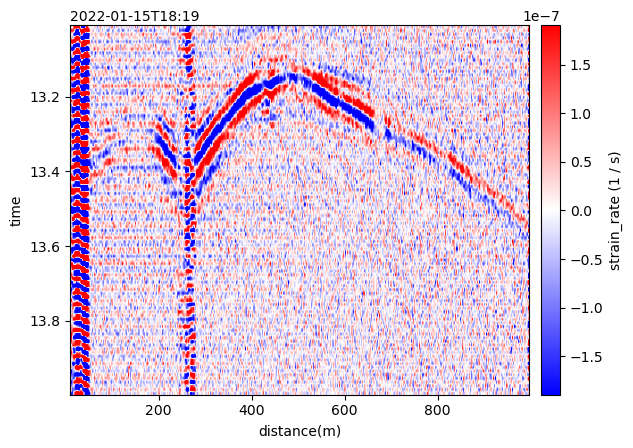

In [18]:
patch2 = patch.select(time = ('2022-01-15T18:19:13', '2022-01-15T18:19:14'))

patch3 = patch2.velocity_to_strain_rate()

dt1 = patch3.detrend("time")
dt2 = dt1.detrend("distance")

dt2.viz.waterfall(interpolation=None)

<Axes: xlabel='distance(m)', ylabel='time'>

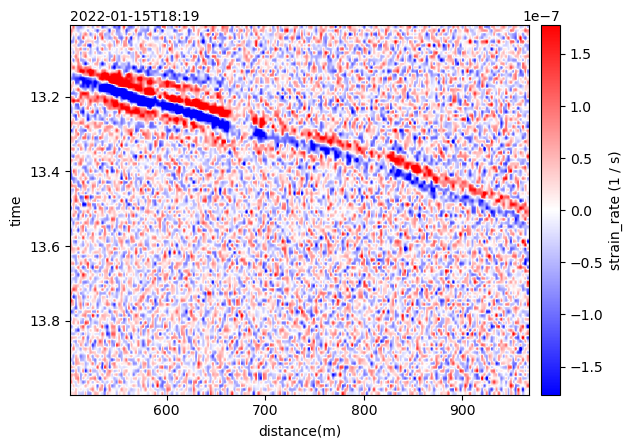

In [34]:
pa_sel = dt2.select(distance = (500, 970))
pa_sel.viz.waterfall()

(100.0, 3000.0)

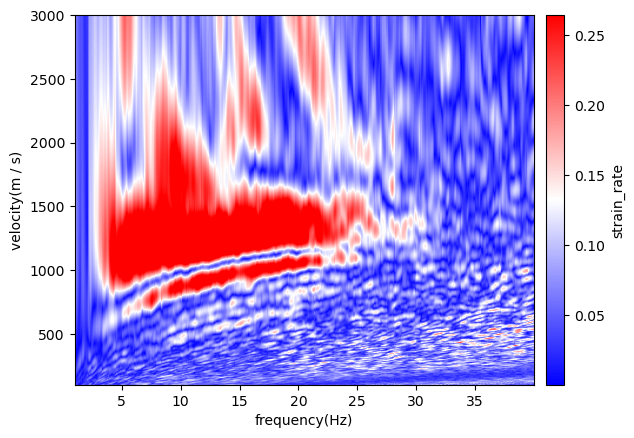

In [35]:
dsp = pa_sel.dispersion_phase_shift(np.arange(100,3000,1),
        approx_resolution=0.1,approx_freq=[1,40])
dsp.viz.waterfall()
plt.ylim(100, 3000)

<Axes: xlabel='distance(m)', ylabel='time'>

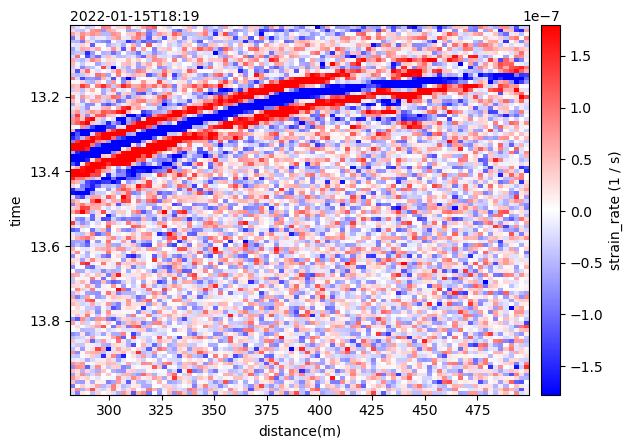

In [60]:
pa_sel2 = dt2.select(distance = (280, 500))
pa_sel2.viz.waterfall(interpolation=None)

(100.0, 3000.0)

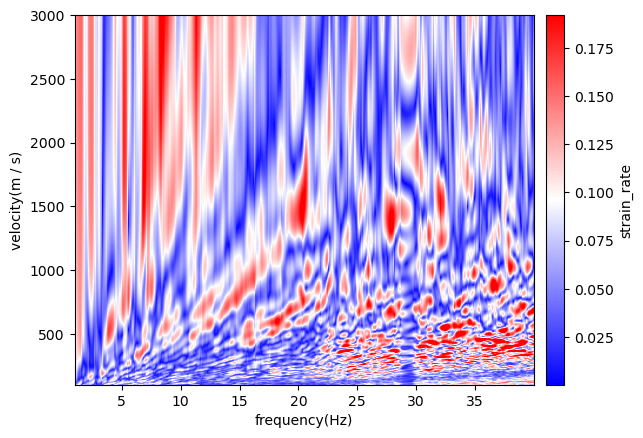

In [61]:
dsp = pa_sel2.dispersion_phase_shift(np.arange(100,3000,1),
        approx_resolution=0.1,approx_freq=[1,40])
dsp.viz.waterfall()
plt.ylim(100, 3000)

<Axes: xlabel='distance', ylabel='time'>

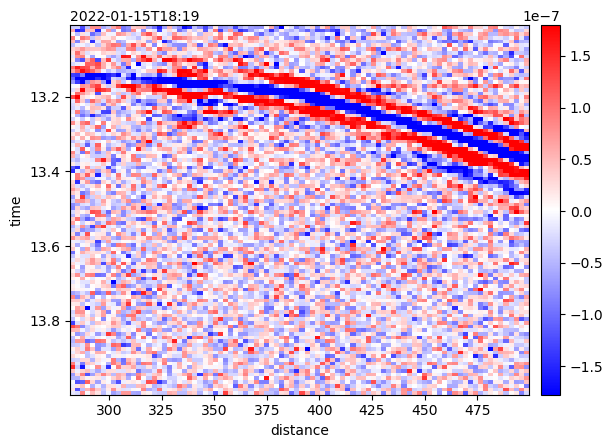

In [62]:
f_pa_sel2 = flip_and_patchify(pa_sel2)

f_pa_sel2.viz.waterfall()

(100.0, 3000.0)

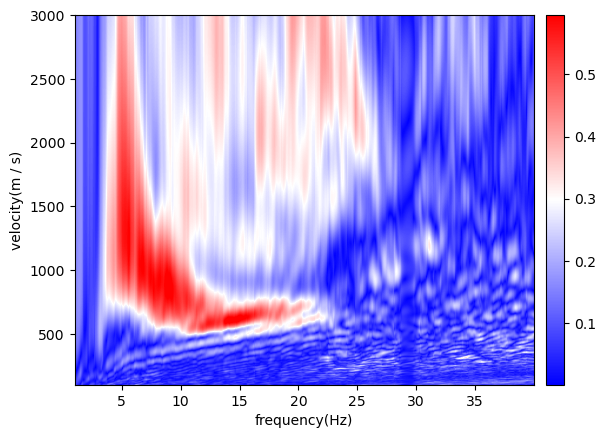

In [65]:
dsp = f_pa_sel2.dispersion_phase_shift(np.arange(100, 3000,1),
        approx_resolution=.1,approx_freq=[1,40])
dsp.viz.waterfall()
plt.ylim(100, 3000)